In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [4]:
import zipfile

In [5]:
with zipfile.ZipFile('/content/healthcare_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/healthcare_data')

In [6]:
import os
os.listdir('/content/healthcare_data')

['Final_Augmented_dataset_Diseases_and_Symptoms.csv']

In [10]:
import pandas as pd

df = pd.read_csv('/content/healthcare_data/Final_Augmented_dataset_Diseases_and_Symptoms.csv')
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [14]:
df.isnull().sum()

,0
diseases,0
anxiety and nervousness,0
depression,0
shortness of breath,0
depressive or psychotic symptoms,0
...,...
hip weakness,0
back swelling,0
ankle stiffness or tightness,0
ankle weakness,0


In [15]:
X = df.drop('diseases', axis=1)
X.head()

,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_sample = X_scaled[:10000]

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
k_rng = range(1,10)

for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_sample)
    sse.append(km.inertia_)

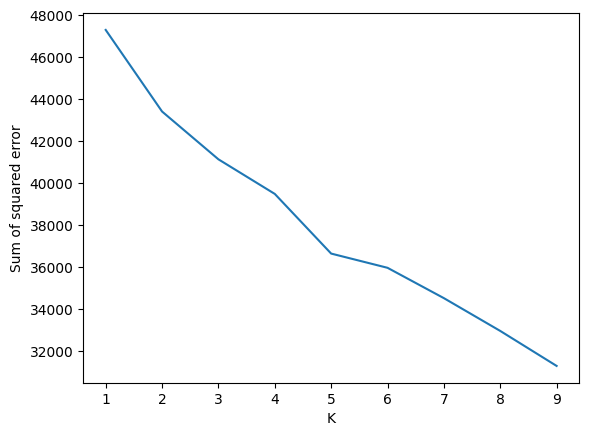

In [19]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)

In [20]:
km = KMeans(n_clusters=5, random_state=42)
y_predicted = km.fit_predict(X_scaled)
y_predicted

array([4, 4, 4, ..., 4, 4, 4], dtype=int32)

In [21]:
df['cluster'] = y_predicted
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness,cluster
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,4
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,4
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,4
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,4


In [22]:
km.cluster_centers_

array([[-1.92207361e-15,  1.44051437e-14, -1.47520884e-14, ...,
         0.00000000e+00, -6.87113127e-18,  0.00000000e+00],
       [ 1.70696790e-15,  2.11967054e-04,  1.14462209e-02, ...,
         0.00000000e+00,  2.72529070e-04,  0.00000000e+00],
       [ 2.01074311e-04,  2.03032036e-14,  1.82202051e-01, ...,
         0.00000000e+00,  3.58870919e-17,  0.00000000e+00],
       [ 8.40315487e-03,  8.52600801e-03,  8.01739600e-02, ...,
         0.00000000e+00,  4.09421845e-17,  0.00000000e+00],
       [ 7.60759782e-02,  8.30971231e-02,  9.25455316e-02, ...,
         0.00000000e+00,  7.33066171e-05,  0.00000000e+00]])

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [24]:
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
plot_df['cluster'] = y_predicted
plot_df.head()

,PC1,PC2,cluster
0,-0.116476,0.340710,4
1,-0.086239,0.258836,4
2,-0.162391,0.274165,4
3,-0.210413,-0.028478,4
4,-0.239094,0.018584,4


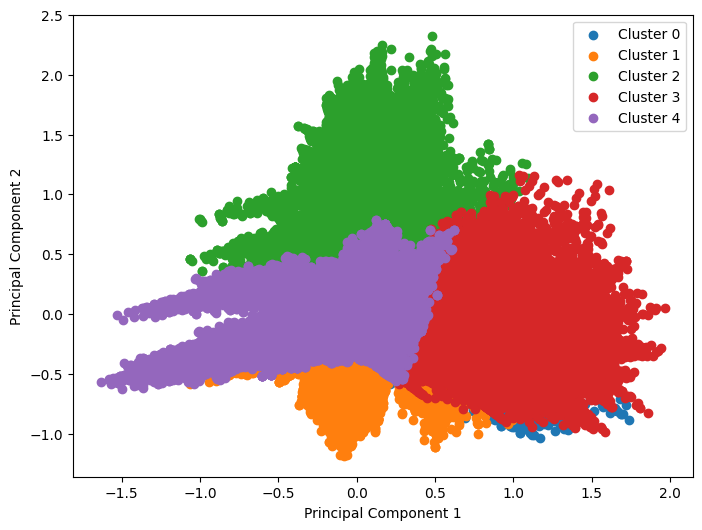

In [25]:
plt.figure(figsize=(8,6))

for i in range(5):
    temp = plot_df[plot_df.cluster == i]
    plt.scatter(temp.PC1, temp.PC2, label=f'Cluster {i}')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [26]:
df.groupby('cluster').size()

,0
cluster,
0,15643
1,33045
2,34813
3,40699
4,122745


In [28]:
cluster_profile = df.drop('diseases', axis=1).groupby('cluster').mean()
cluster_profile

,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.004539,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
1,0.000000,0.000212,0.011439,0.000151,0.057770,0.026388,0.004539,0.048510,0.000121,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000272,0.0
2,0.000201,0.000000,0.182202,0.004539,0.146181,0.020826,0.006262,0.000000,0.083044,0.012524,...,0.0,0.0,0.0,0.0,0.005113,0.0,0.0,0.0,0.000000,0.0
3,0.008403,0.008526,0.080174,0.012040,0.163616,0.075555,0.006855,0.005062,0.019411,0.003514,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
4,0.076093,0.083115,0.092566,0.117406,0.083816,0.102652,0.074015,0.066887,0.046169,0.045330,...,0.0,0.0,0.0,0.0,0.001336,0.0,0.0,0.0,0.000073,0.0


In [29]:
for i in range(5):
    print(f"\nCluster {i}")
    print(cluster_profile.loc[i].sort_values(ascending=False).head(10))


Cluster 0
painful urination        0.481685
suprapubic pain          0.454133
frequent urination       0.398837
retention of urine       0.395896
blood in urine           0.389631
sharp abdominal pain     0.328390
lower abdominal pain     0.270217
involuntary urination    0.251614
back pain                0.218117
side pain                0.193185
Name: 0, dtype: float64

Cluster 1
leg pain               0.422000
back pain              0.347193
arm pain               0.304978
low back pain          0.284491
hip pain               0.272840
neck pain              0.252080
loss of sensation      0.230625
shoulder pain          0.218429
knee pain              0.216493
hand or finger pain    0.171857
Name: 1, dtype: float64

Cluster 2
cough                  0.637808
nasal congestion       0.430443
fever                  0.416454
sore throat            0.346968
coryza                 0.215695
ear pain               0.202252
shortness of breath    0.182202
vomiting               0.173929
hea